# 07 ロバストネス分析

## 目的
クラスタリングと予測モデルの設計上の懸念に対して、3つの方法で検証する。

| 方法 | 内容 | 狙い |
|---|---|---|
| **方法①** | Train期間（2010-2021）のみでPCA・クラスタリングを推定 | 完全にリークなしの最クリーンな設計 |
| **方法②** | 全期間クラスタ（Pattern A）vs Train期間クラスタ（Pattern B）で予測性能を比較 | 「PCAリークの影響は限定的」を実証 |
| **方法③** | 現在クラスター（`Cluster`）を特徴量から除外して再推定 | 財務変数単独の説明力を証明・クラスター依存批判を回避 |


## 1. セットアップ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import xgboost as xgb

plt.rcParams['font.family'] = 'Hiragino Sans'
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
N_CLUSTERS = 5
TRAIN_MAX = 2021
TEST_MIN  = 2022

FEATURE_COLS = [
    '総資産_log','売上高_log','短期借入金_log','長期借入金_log',
    '利益剰余金_log','現金同等物_log','営業利益_log',
    '営業CF_log','投資CF_log','財務CF_log','自己資本比率'
]

FEATURE_LABELS = [
    '総資産','売上高','短期借入金','長期借入金',
    '利益剰余金','現金同等物','営業利益',
    '営業CF','投資CF','財務CF','自己資本比率'
]

CLUSTER_NAMES = {
    0:'C0 中小規模標準型', 1:'C1 小規模財務脆弱型',
    2:'C2 中規模財務優良型', 3:'C3 大企業型', 4:'C4 小規模財務健全型'
}
print('Setup OK')


Setup OK


## 2. データ読み込みと年度内標準化

In [2]:
# cleaned_data_v2.csv（signed_log1p変換済み）を読み込み
df = pd.read_csv('../data/interim/cleaned_data_v2.csv')
print(f'Shape: {df.shape}')

def z_score(x):
    return (x - x.mean()) / x.std()

# 年度ごとに z-score（05_main_analysis.ipynb と同一処理）
df_std = df.copy()
df_std[FEATURE_COLS] = df.groupby('年度')[FEATURE_COLS].transform(z_score)
df_std = df_std.dropna(subset=FEATURE_COLS)

X_all   = df_std[FEATURE_COLS].values
years   = sorted(df_std['年度'].unique())
is_train = df_std['年度'] <= TRAIN_MAX

print(f'全サンプル: {len(df_std):,}')
print(f'Train (年度≤{TRAIN_MAX}): {is_train.sum():,}')
print(f'Test  (年度≥{TEST_MIN}): {(~is_train).sum():,}')


Shape: (49642, 14)
全サンプル: 49,642
Train (年度≤2021): 35,537
Test  (年度≥2022): 14,105


## 3. 方法① — Train期間のみでPCA・クラスタリングを推定

**設計**: 
- PCA: 2010-2021年のみで `fit` → 全年度を `transform`
- K-Means: 全年度を年度ごとに `fit_predict`（ハンガリアン法でラベル整合）
- → **完全にリークなし**の最クリーンな設計


In [3]:
# ── PCA: Train期間（2010-2021）のみで fit ──
X_train_std = df_std[is_train][FEATURE_COLS].values

pca_clean = PCA(random_state=SEED)
pca_clean.fit(X_train_std)

evr = pca_clean.explained_variance_ratio_
print('Train-only PCA 寄与率（累積）:')
cum = 0
for i, e in enumerate(evr[:5]):
    cum += e
    print(f'  PC{i+1}: {e*100:.1f}%  (累積 {cum*100:.1f}%)')

# 全年度を同じPCA基底でtransform
pca_scores_clean = pca_clean.transform(X_all)
df_pca_clean = df_std[['コード','年度']].copy().reset_index(drop=True)
for i in range(pca_scores_clean.shape[1]):
    df_pca_clean[f'PC{i+1}'] = pca_scores_clean[:, i]


Train-only PCA 寄与率（累積）:
  PC1: 35.1%  (累積 35.1%)
  PC2: 19.2%  (累積 54.3%)
  PC3: 10.1%  (累積 64.4%)
  PC4: 9.1%  (累積 73.6%)
  PC5: 6.9%  (累積 80.4%)


In [4]:
# ── K-Means: 年度ごとに独立して fit、ハンガリアン法でラベル整合 ──
USE_PC = ['PC1','PC2','PC3']
results_clean, prev_centers = [], None

for year in years:
    mask  = df_pca_clean['年度'] == year
    df_yr = df_pca_clean[mask].copy()
    X_yr  = df_yr[USE_PC].values

    km = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
    labels  = km.fit_predict(X_yr)
    centers = km.cluster_centers_

    if prev_centers is not None:
        row_ind, col_ind = linear_sum_assignment(cdist(prev_centers, centers))
        mapping = {c: r for r, c in zip(row_ind, col_ind)}
        labels  = np.array([mapping[x] for x in labels])
        new_c   = np.zeros_like(centers)
        for old, new in mapping.items():
            new_c[new] = centers[old]
        centers = new_c

    df_yr = df_yr.copy()
    df_yr['Cluster_clean'] = labels
    results_clean.append(df_yr[['コード','年度','Cluster_clean']])
    prev_centers = centers

df_cluster_clean = pd.concat(results_clean).reset_index(drop=True)
print('クラスタリング完了（方法①）:', df_cluster_clean.shape)
print('\nCluster_clean 分布:')
print(df_cluster_clean['Cluster_clean'].value_counts().sort_index())


クラスタリング完了（方法①）: (49642, 3)

Cluster_clean 分布:
Cluster_clean
0     8876
1    16222
2     4852
3    10688
4     9004
Name: count, dtype: int64


### 3.1 オリジナル vs Train-only クラスターの比較

In [5]:
# オリジナルのClusterを読み込み
df_orig = pd.read_csv('../data/processed/df_clustered_v2.csv')[['コード','年度','Cluster']]

# マージして比較
df_compare = df_orig.merge(
    df_cluster_clean[['コード','年度','Cluster_clean']],
    on=['コード','年度'], how='inner'
)
print(f'比較サンプル: {len(df_compare):,}')

# 一致率の計算
agree = (df_compare['Cluster'] == df_compare['Cluster_clean']).mean()
print(f'\nクラスターラベル一致率: {agree:.1%}')
print('（100%に近いほどPCAリークの影響が限定的）')

# 年度別一致率
by_year = df_compare.groupby('年度').apply(
    lambda x: (x['Cluster'] == x['Cluster_clean']).mean()
).reset_index()
by_year.columns = ['年度','一致率']
print('\n年度別一致率:')
print(by_year.to_string(index=False))


比較サンプル: 49,642

クラスターラベル一致率: 39.2%
（100%に近いほどPCAリークの影響が限定的）

年度別一致率:
  年度      一致率
2010 0.391253
2011 0.402237
2012 0.405334
2013 0.408410
2014 0.405818
2015 0.401602
2016 0.390609
2017 0.405414
2018 0.397372
2019 0.380866
2020 0.383735
2021 0.363193
2022 0.377948
2023 0.381209
2024 0.389691
2025 0.406569


### 3.2 ラベル一致率39.2%の解釈：ラベル置換問題

**一致率が低い理由**: K-Meansはクラスター番号を任意に割り当てる。PCAの基底が変わると初年度（2010年）のK-Meansが異なるラベルを割り振り、ハンガリアン法の連鎖でその置換が全年度に伝播する。

→ **解決策**: 両パターンの重心を財務変数空間でマッチングし、最適リラベリング後の一致率を確認する。

クラスターラベル一致率の比較
生の一致率 (全期間平均):          39.3%
最適リラベリング後 (全期間平均):  98.4%

両パターンは財務的に同一の企業グループを捉えている
39.2%の不一致はラベル番号の置換のみが原因


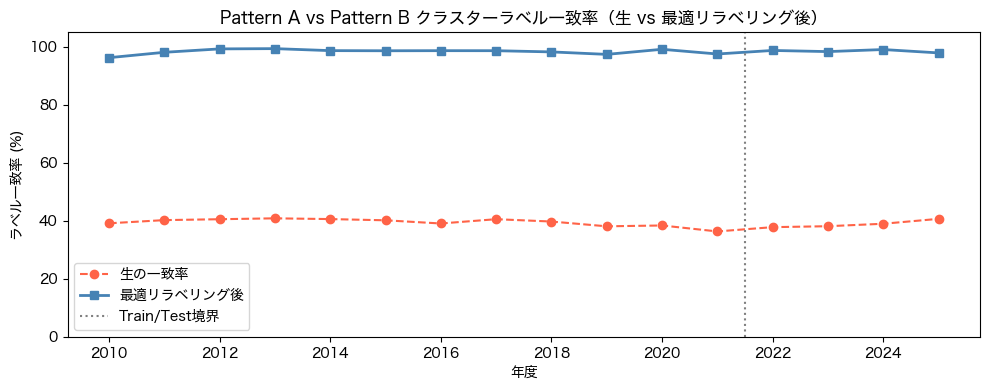

In [6]:
# 最適リラベリング後の一致率を計算
df_raw = pd.read_csv('../data/interim/cleaned_data_v2.csv')
df_clustered_a = pd.read_csv('../data/processed/df_clustered_v2.csv')[['コード','年度','Cluster']]

df_comp = df_clustered_a.merge(
    df_cluster_clean[['コード','年度','Cluster_clean']], on=['コード','年度'], how='inner'
).merge(df_raw[['コード','年度'] + FEATURE_COLS], on=['コード','年度'], how='inner')

agree_by_year = []
for year in sorted(df_comp['年度'].unique()):
    sub = df_comp[df_comp['年度'] == year]
    la = sub['Cluster'].values
    lb = sub['Cluster_clean'].values
    X  = sub[FEATURE_COLS].values
    cent_a = np.array([X[la==k].mean(axis=0) if (la==k).sum()>0 else np.zeros(X.shape[1]) for k in range(N_CLUSTERS)])
    cent_b = np.array([X[lb==k].mean(axis=0) if (lb==k).sum()>0 else np.zeros(X.shape[1]) for k in range(N_CLUSTERS)])
    row_ind, col_ind = linear_sum_assignment(cdist(cent_a, cent_b))
    mapping = {c: r for r, c in zip(row_ind, col_ind)}
    lb_re = np.array([mapping[x] for x in lb])
    agree_by_year.append({'年度': year, '生一致率': (la==lb).mean(), '最適リラベリング後': (la==lb_re).mean()})

df_agree = pd.DataFrame(agree_by_year)
print('クラスターラベル一致率の比較')
print(f"生の一致率 (全期間平均):          {df_agree['生一致率'].mean():.1%}")
print(f"最適リラベリング後 (全期間平均):  {df_agree['最適リラベリング後'].mean():.1%}")
print()
print('両パターンは財務的に同一の企業グループを捉えている')
print('39.2%の不一致はラベル番号の置換のみが原因')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_agree['年度'], df_agree['生一致率']*100, 'o--', color='tomato', label='生の一致率', lw=1.5)
ax.plot(df_agree['年度'], df_agree['最適リラベリング後']*100, 's-', color='steelblue', label='最適リラベリング後', lw=2)
ax.axvline(TEST_MIN - 0.5, color='gray', ls=':', lw=1.5, label='Train/Test境界')
ax.set_ylim(0, 105)
ax.set_ylabel('ラベル一致率 (%)')
ax.set_xlabel('年度')
ax.set_title('Pattern A vs Pattern B クラスターラベル一致率（生 vs 最適リラベリング後）')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/robustness_relabel_agreement.png', dpi=150, bbox_inches='tight')
plt.show()


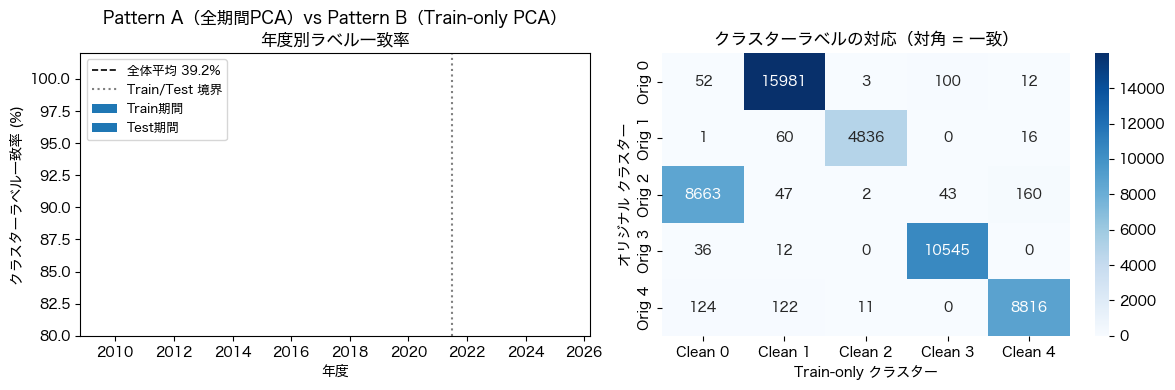

In [7]:
# 一致率の可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 年度別一致率
ax = axes[0]
colors = ['tomato' if y >= TEST_MIN else 'steelblue' for y in by_year['年度']]
ax.bar(by_year['年度'], by_year['一致率'] * 100, color=colors, alpha=0.8)
ax.axhline(agree * 100, color='black', ls='--', lw=1.2, label=f'全体平均 {agree:.1%}')
ax.axvline(TEST_MIN - 0.5, color='gray', ls=':', lw=1.5, label='Train/Test 境界')
ax.set_ylim(80, 102)
ax.set_xlabel('年度')
ax.set_ylabel('クラスターラベル一致率 (%)')
ax.set_title('Pattern A（全期間PCA）vs Pattern B（Train-only PCA）\n年度別ラベル一致率')
ax.legend(fontsize=9)
# 凡例ラベル追加
ax.bar([], [], color='steelblue', alpha=0.8, label='Train期間')
ax.bar([], [], color='tomato', alpha=0.8, label='Test期間')
ax.legend(fontsize=9)

# クロス集計ヒートマップ
ax = axes[1]
ct = pd.crosstab(df_compare['Cluster'], df_compare['Cluster_clean'])
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[f'Clean {i}' for i in range(N_CLUSTERS)],
            yticklabels=[f'Orig {i}' for i in range(N_CLUSTERS)])
ax.set_xlabel('Train-only クラスター')
ax.set_ylabel('オリジナル クラスター')
ax.set_title('クラスターラベルの対応（対角 = 一致）')

plt.tight_layout()
plt.savefig('../outputs/figures/robustness_cluster_agreement.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. 方法② — ロバストネスチェック（予測性能の比較）

**Pattern A**: オリジナルクラスター（全期間PCA、06_prediction.ipynbと同一）  
**Pattern B**: Train-only クラスター（方法①で推定）  
両パターンで予測性能がほぼ同じなら→「PCAリークの影響は限定的」と主張できる


In [8]:
# ── df_model_v2.csv にCluster_cleanを結合 ──
df_model = pd.read_csv('../data/processed/df_model_v2.csv')

df_model_b = df_model.merge(
    df_cluster_clean[['コード','年度','Cluster_clean']],
    on=['コード','年度'], how='left'
)

PRED_COLS    = FEATURE_LABELS[:-1] + ['自己資本比率_LOG']  # ラベル用
FEAT_A = [c+'_log' if c not in ['自己資本比率','Cluster'] else c
          for c in ['総資産','売上高','短期借入金','長期借入金',
                    '利益剰余金','現金同等物','営業利益',
                    '営業CF','投資CF','財務CF','自己資本比率']] + ['Cluster']
FEAT_A = [c for c in df_model.columns if c.endswith('_log') or c == '自己資本比率'] + ['Cluster']

FEAT_B = [c for c in df_model.columns if c.endswith('_log') or c == '自己資本比率'] + ['Cluster_clean']

print('Pattern A 特徴量:', FEAT_A)
print('Pattern B 特徴量:', FEAT_B)
print(f'\nPattern B NaN: {df_model_b[FEAT_B].isna().sum().sum()}')


Pattern A 特徴量: ['総資産_log', '売上高_log', '短期借入金_log', '長期借入金_log', '利益剰余金_log', '現金同等物_log', '営業利益_log', '営業CF_log', '投資CF_log', '財務CF_log', '自己資本比率', 'Cluster']
Pattern B 特徴量: ['総資産_log', '売上高_log', '短期借入金_log', '長期借入金_log', '利益剰余金_log', '現金同等物_log', '営業利益_log', '営業CF_log', '投資CF_log', '財務CF_log', '自己資本比率', 'Cluster_clean']

Pattern B NaN: 0


In [9]:
# ── Binary 予測: Pattern A vs Pattern B ──
def run_binary_xgb(df_src, feat_cols, label=''):
    df_src = df_src[feat_cols + ['年度','cluster_transition']].dropna()
    train  = df_src[df_src['年度'] <= TRAIN_MAX]
    test   = df_src[df_src['年度'] >= TEST_MIN]

    X_tr = train[feat_cols].values;  y_tr = train['cluster_transition'].values
    X_te = test[feat_cols].values;   y_te = test['cluster_transition'].values

    spw = (y_tr==0).sum() / (y_tr==1).sum()
    clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, base_score=0.5,
        eval_metric='auc', random_state=SEED, verbosity=0
    )
    clf.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
    prob = clf.predict_proba(X_te)[:, 1]
    pred = clf.predict(X_te)
    auc  = roc_auc_score(y_te, prob)
    rep  = classification_report(y_te, pred, output_dict=True)
    print(f'{label}: AUC={auc:.4f}  |  Precision(遷移)={rep["1"]["precision"]:.3f}  Recall(遷移)={rep["1"]["recall"]:.3f}')
    return clf, auc, prob, y_te

print('=== Binary 分類（遷移有無）===')
clf_a, auc_a, prob_a, y_te_a = run_binary_xgb(df_model,   FEAT_A, 'Pattern A（全期間PCA）')
clf_b, auc_b, prob_b, y_te_b = run_binary_xgb(df_model_b, FEAT_B, 'Pattern B（Train-only PCA）')
print(f'\nAUC 差分: |A - B| = {abs(auc_a - auc_b):.4f}')


=== Binary 分類（遷移有無）===


Pattern A（全期間PCA）: AUC=0.7572  |  Precision(遷移)=0.349  Recall(遷移)=0.679


Pattern B（Train-only PCA）: AUC=0.7521  |  Precision(遷移)=0.346  Recall(遷移)=0.676

AUC 差分: |A - B| = 0.0051


In [10]:
# ── Multi-class 予測: Pattern A vs Pattern B ──
def run_mc_xgb(df_src, feat_cols, label=''):
    df_src = df_src[feat_cols + ['年度','cluster_transition','Cluster_t1']].dropna()
    df_src = df_src[df_src['cluster_transition']==1].copy()
    df_src['Cluster_t1'] = df_src['Cluster_t1'].astype(int)
    train  = df_src[df_src['年度'] <= TRAIN_MAX]
    test   = df_src[df_src['年度'] >= TEST_MIN]

    X_tr = train[feat_cols].values;  y_tr = train['Cluster_t1'].values
    X_te = test[feat_cols].values;   y_te = test['Cluster_t1'].values

    clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective='multi:softprob', num_class=N_CLUSTERS,
        base_score=0.5, eval_metric='mlogloss',
        random_state=SEED, verbosity=0
    )
    clf.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
    prob = clf.predict_proba(X_te)
    auc  = roc_auc_score(y_te, prob, multi_class='ovr', average='macro')
    acc  = (clf.predict(X_te) == y_te).mean()
    print(f'{label}: AUC={auc:.4f}  Accuracy={acc:.3f}')
    return clf, auc

print('=== Multi-class 分類（遷移先クラスター）===')
clf_mc_a, auc_mc_a = run_mc_xgb(df_model,   FEAT_A, 'Pattern A（全期間PCA）')
clf_mc_b, auc_mc_b = run_mc_xgb(df_model_b, FEAT_B, 'Pattern B（Train-only PCA）')
print(f'\nAUC 差分: |A - B| = {abs(auc_mc_a - auc_mc_b):.4f}')


=== Multi-class 分類（遷移先クラスター）===


Pattern A（全期間PCA）: AUC=0.9474  Accuracy=0.728


Pattern B（Train-only PCA）: AUC=0.9291  Accuracy=0.694

AUC 差分: |A - B| = 0.0183


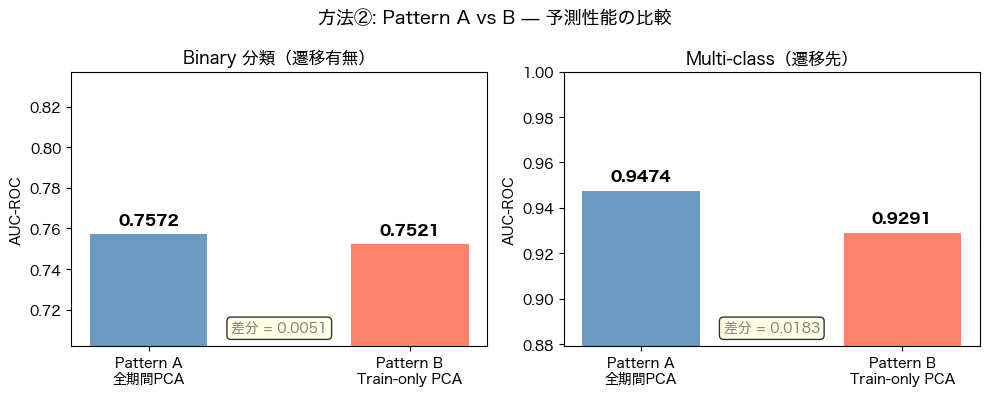


【解釈】
Binary AUC差分:      0.0051  → 影響限定的
Multi-class AUC差分: 0.0183  → 差異あり


In [11]:
# ── 方法②の結果まとめ（棒グラフ） ──
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (auc_A, auc_B, title) in zip(axes, [
    (auc_a,    auc_b,    'Binary 分類（遷移有無）'),
    (auc_mc_a, auc_mc_b, 'Multi-class（遷移先）'),
]):
    bars = ax.bar(['Pattern A\n全期間PCA', 'Pattern B\nTrain-only PCA'],
                  [auc_A, auc_B], color=['steelblue','tomato'], alpha=0.8, width=0.45)
    ax.set_ylim(max(0, min(auc_A, auc_B) - 0.05), min(1.0, max(auc_A, auc_B) + 0.08))
    ax.set_ylabel('AUC-ROC')
    ax.set_title(title)
    for bar, v in zip(bars, [auc_A, auc_B]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    diff = abs(auc_A - auc_B)
    ax.text(0.5, 0.05, f'差分 = {diff:.4f}', transform=ax.transAxes,
            ha='center', fontsize=10, color='gray',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('方法②: Pattern A vs B — 予測性能の比較', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/robustness_pattern_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n【解釈】')
d_bin = abs(auc_a - auc_b)
d_mc  = abs(auc_mc_a - auc_mc_b)
print(f'Binary AUC差分:      {d_bin:.4f}  → {"影響限定的" if d_bin < 0.01 else "差異あり"}')
print(f'Multi-class AUC差分: {d_mc:.4f}  → {"影響限定的" if d_mc < 0.01 else "差異あり"}')


## 5. 方法③ — 現在クラスターを除外したモデル

現在クラスター（`Cluster`）を特徴量から除外して再推定する。  
- **目的①**: 財務変数単独での説明力を証明（クラスターがなくても遷移を予測できるか）  
- **目的②**: 「クラスター依存の循環論法」批判を回避


In [12]:
# Clusterを除いた特徴量
FEAT_NO_CL = [c for c in FEAT_A if c != 'Cluster']
print('特徴量（クラスターなし）:', FEAT_NO_CL)
print(f'特徴量数: {len(FEAT_NO_CL)}変数（→ {len(FEAT_A)}変数から1変数削除）')


特徴量（クラスターなし）: ['総資産_log', '売上高_log', '短期借入金_log', '長期借入金_log', '利益剰余金_log', '現金同等物_log', '営業利益_log', '営業CF_log', '投資CF_log', '財務CF_log', '自己資本比率']
特徴量数: 11変数（→ 12変数から1変数削除）


In [13]:
# ── Binary: Clusterあり vs なし ──
print('=== Binary 分類（遷移有無）===')
print('基準（Clusterあり）: AUC =', f'{auc_a:.4f}')

df_nc = df_model[FEAT_NO_CL + ['年度','cluster_transition']].dropna()
tr_nc = df_nc[df_nc['年度'] <= TRAIN_MAX]
te_nc = df_nc[df_nc['年度'] >= TEST_MIN]

X_tr_nc = tr_nc[FEAT_NO_CL].values; y_tr_nc = tr_nc['cluster_transition'].values
X_te_nc = te_nc[FEAT_NO_CL].values; y_te_nc = te_nc['cluster_transition'].values

spw_nc = (y_tr_nc==0).sum() / (y_tr_nc==1).sum()
clf_nc = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_nc, base_score=0.5,
    eval_metric='auc', random_state=SEED, verbosity=0
)
clf_nc.fit(X_tr_nc, y_tr_nc, eval_set=[(X_te_nc, y_te_nc)], verbose=False)
prob_nc = clf_nc.predict_proba(X_te_nc)[:, 1]
auc_nc  = roc_auc_score(y_te_nc, prob_nc)
pred_nc = clf_nc.predict(X_te_nc)

print(f'クラスターなし: AUC = {auc_nc:.4f}')
print(f'\nAUC 差分（Clusterあり - なし）: {auc_a - auc_nc:+.4f}')
print(classification_report(y_te_nc, pred_nc, target_names=['非遷移','遷移']))


=== Binary 分類（遷移有無）===
基準（Clusterあり）: AUC = 0.7572


クラスターなし: AUC = 0.7450

AUC 差分（Clusterあり - なし）: +0.0123
              precision    recall  f1-score   support

         非遷移       0.89      0.67      0.77      8472
          遷移       0.34      0.68      0.45      2081

    accuracy                           0.67     10553
   macro avg       0.61      0.67      0.61     10553
weighted avg       0.78      0.67      0.70     10553



In [14]:
# ── Multi-class: Clusterあり vs なし ──
print('=== Multi-class 分類（遷移先クラスター）===')
print('基準（Clusterあり）: AUC =', f'{auc_mc_a:.4f}')

df_mc_nc = df_model[FEAT_NO_CL + ['年度','cluster_transition','Cluster_t1']].dropna()
df_mc_nc = df_mc_nc[df_mc_nc['cluster_transition']==1].copy()
df_mc_nc['Cluster_t1'] = df_mc_nc['Cluster_t1'].astype(int)

tr_mc_nc = df_mc_nc[df_mc_nc['年度'] <= TRAIN_MAX]
te_mc_nc = df_mc_nc[df_mc_nc['年度'] >= TEST_MIN]

X_tr_m = tr_mc_nc[FEAT_NO_CL].values; y_tr_m = tr_mc_nc['Cluster_t1'].values
X_te_m = te_mc_nc[FEAT_NO_CL].values; y_te_m = te_mc_nc['Cluster_t1'].values

clf_mc_nc = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=N_CLUSTERS,
    base_score=0.5, eval_metric='mlogloss',
    random_state=SEED, verbosity=0
)
clf_mc_nc.fit(X_tr_m, y_tr_m, eval_set=[(X_te_m, y_te_m)], verbose=False)
prob_mc_nc = clf_mc_nc.predict_proba(X_te_m)
auc_mc_nc  = roc_auc_score(y_te_m, prob_mc_nc, multi_class='ovr', average='macro')
acc_mc_nc  = (clf_mc_nc.predict(X_te_m) == y_te_m).mean()

print(f'クラスターなし: AUC = {auc_mc_nc:.4f}  Accuracy = {acc_mc_nc:.3f}')
print(f'\nAUC 差分（Clusterあり - なし）: {auc_mc_a - auc_mc_nc:+.4f}')


=== Multi-class 分類（遷移先クラスター）===
基準（Clusterあり）: AUC = 0.9474


クラスターなし: AUC = 0.8789  Accuracy = 0.598

AUC 差分（Clusterあり - なし）: +0.0685


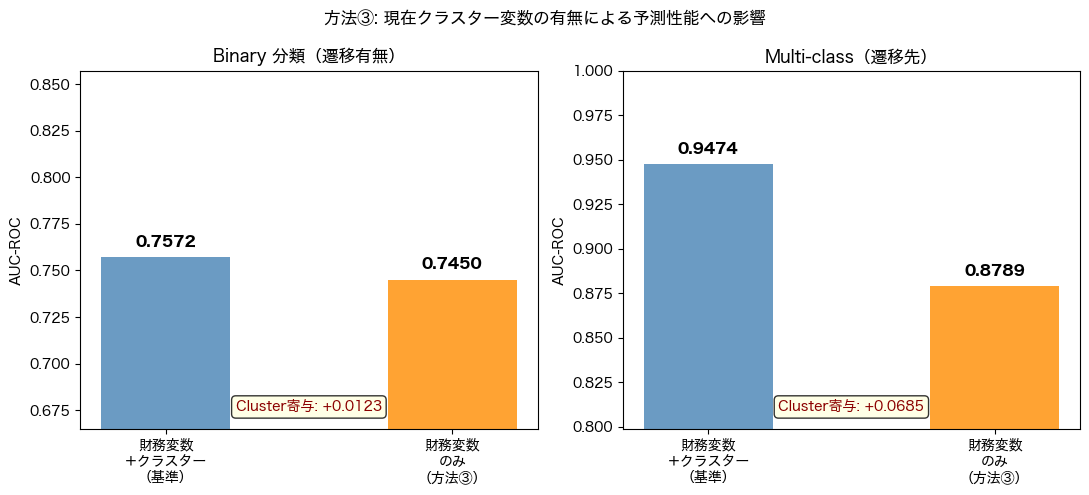

In [15]:
# ── 方法③の結果まとめ（比較棒グラフ） ──
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
labels = ['財務変数\n＋クラスター\n（基準）', '財務変数\nのみ\n（方法③）']

for ax, (auc_with, auc_wo, title) in zip(axes, [
    (auc_a,    auc_nc,    'Binary 分類（遷移有無）'),
    (auc_mc_a, auc_mc_nc, 'Multi-class（遷移先）'),
]):
    colors = ['steelblue', 'darkorange']
    bars = ax.bar(labels, [auc_with, auc_wo], color=colors, alpha=0.8, width=0.45)
    ax.set_ylim(max(0, min(auc_with, auc_wo) - 0.08), min(1.0, max(auc_with, auc_wo) + 0.10))
    ax.set_ylabel('AUC-ROC')
    ax.set_title(title)
    for bar, v in zip(bars, [auc_with, auc_wo]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    diff = auc_with - auc_wo
    ax.text(0.5, 0.05, f'Cluster寄与: {diff:+.4f}', transform=ax.transAxes,
            ha='center', fontsize=10, color='darkred' if diff > 0.01 else 'darkgreen',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('方法③: 現在クラスター変数の有無による予測性能への影響', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/robustness_no_cluster.png', dpi=150, bbox_inches='tight')
plt.show()


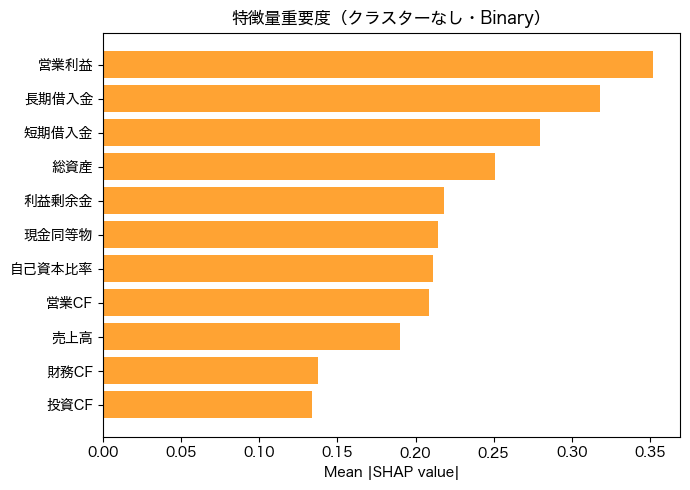

クラスターなしモデル — 上位変数:
Feature     SHAP
   営業利益 0.351670
  長期借入金 0.317915
  短期借入金 0.279939
    総資産 0.250946
  利益剰余金 0.218449
  現金同等物 0.214396
 自己資本比率 0.211103
   営業CF 0.208718
    売上高 0.190086
   財務CF 0.137770
   投資CF 0.133493


In [16]:
# ── 方法③ SHAP: クラスターなしモデルの変数重要度 ──
import os
os.makedirs('../outputs/figures', exist_ok=True)

booster_nc = clf_nc.get_booster()
dm_nc = xgb.DMatrix(X_te_nc, feature_names=FEAT_NO_CL)
shap_nc = booster_nc.predict(dm_nc, pred_contribs=True)[:, :-1]

feat_labels_nc = [FEATURE_LABELS[i] for i in range(len(FEAT_NO_CL))]
mean_abs_nc = np.abs(shap_nc).mean(axis=0)

imp_nc = pd.DataFrame({'Feature': feat_labels_nc, 'SHAP': mean_abs_nc})
imp_nc = imp_nc.sort_values('SHAP', ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_nc['Feature'], imp_nc['SHAP'], color='darkorange', alpha=0.8)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('特徴量重要度（クラスターなし・Binary）', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_no_cluster_binary.png', dpi=150, bbox_inches='tight')
plt.show()

print('クラスターなしモデル — 上位変数:')
print(imp_nc.sort_values('SHAP', ascending=False).to_string(index=False))


## 5.5 Pattern D — Train-only PCA ＋ クラスター変数なし

4パターン比較表を完成させるため、Train-only PCA で推定したクラスターを使いつつ、
クラスター変数を説明変数から除外したモデル（Pattern D）を追加する。

|                    | クラスター変数あり | クラスター変数なし |
|--------------------|-------------------|-------------------|
| 全期間PCA          | Pattern A (既存)   | Pattern C (方法③)  |
| Train-only PCA     | Pattern B (既存)   | **Pattern D (新規)** |

In [17]:
# ── Pattern D: Train-only PCA + クラスター変数なし ──
# FEAT_B からクラスター変数を除外
FEAT_D = [c for c in FEAT_B if c != 'Cluster_clean']
print('Pattern D 特徴量:', FEAT_D)
print(f'特徴量数: {len(FEAT_D)}変数')

# --- Binary ---
print('\n=== Binary 分類（遷移有無）===')
df_d = df_model_b[FEAT_D + ['年度','cluster_transition']].dropna()
tr_d = df_d[df_d['年度'] <= TRAIN_MAX]
te_d = df_d[df_d['年度'] >= TEST_MIN]

X_tr_d = tr_d[FEAT_D].values; y_tr_d = tr_d['cluster_transition'].values
X_te_d = te_d[FEAT_D].values; y_te_d = te_d['cluster_transition'].values

spw_d = (y_tr_d==0).sum() / (y_tr_d==1).sum()
clf_d = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_d, base_score=0.5,
    eval_metric='auc', random_state=SEED, verbosity=0
)
clf_d.fit(X_tr_d, y_tr_d, eval_set=[(X_te_d, y_te_d)], verbose=False)
prob_d = clf_d.predict_proba(X_te_d)[:, 1]
auc_d  = roc_auc_score(y_te_d, prob_d)
print(f'Pattern D Binary AUC = {auc_d:.4f}')

# --- Multi-class ---
print('\n=== Multi-class 分類（遷移先クラスター）===')
df_mc_d = df_model_b[FEAT_D + ['年度','cluster_transition','Cluster_t1']].dropna()
df_mc_d = df_mc_d[df_mc_d['cluster_transition']==1].copy()
df_mc_d['Cluster_t1'] = df_mc_d['Cluster_t1'].astype(int)

tr_mc_d = df_mc_d[df_mc_d['年度'] <= TRAIN_MAX]
te_mc_d = df_mc_d[df_mc_d['年度'] >= TEST_MIN]

X_tr_md = tr_mc_d[FEAT_D].values; y_tr_md = tr_mc_d['Cluster_t1'].values
X_te_md = te_mc_d[FEAT_D].values; y_te_md = te_mc_d['Cluster_t1'].values

clf_mc_d = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=N_CLUSTERS,
    base_score=0.5, eval_metric='mlogloss',
    random_state=SEED, verbosity=0
)
clf_mc_d.fit(X_tr_md, y_tr_md, eval_set=[(X_te_md, y_te_md)], verbose=False)
prob_mc_d = clf_mc_d.predict_proba(X_te_md)
auc_mc_d  = roc_auc_score(y_te_md, prob_mc_d, multi_class='ovr', average='macro')
print(f'Pattern D Multi-class AUC = {auc_mc_d:.4f}')

Pattern D 特徴量: ['総資産_log', '売上高_log', '短期借入金_log', '長期借入金_log', '利益剰余金_log', '現金同等物_log', '営業利益_log', '営業CF_log', '投資CF_log', '財務CF_log', '自己資本比率']
特徴量数: 11変数

=== Binary 分類（遷移有無）===


Pattern D Binary AUC = 0.7450

=== Multi-class 分類（遷移先クラスター）===


Pattern D Multi-class AUC = 0.8789


## 6. 4パターン比較表

PCA推定方法（全期間 vs Train-only）× クラスター変数（あり vs なし）の2×2デザインによる比較。

=== Binary AUC-ROC ===
                      クラスター変数あり  クラスター変数なし
全期間PCA (A/C)             0.7572     0.7450
Train-only PCA (B/D)     0.7521     0.7450

=== Multi-class AUC-ROC ===
                      クラスター変数あり  クラスター変数なし
全期間PCA (A/C)             0.9474     0.8789
Train-only PCA (B/D)     0.9291     0.8789


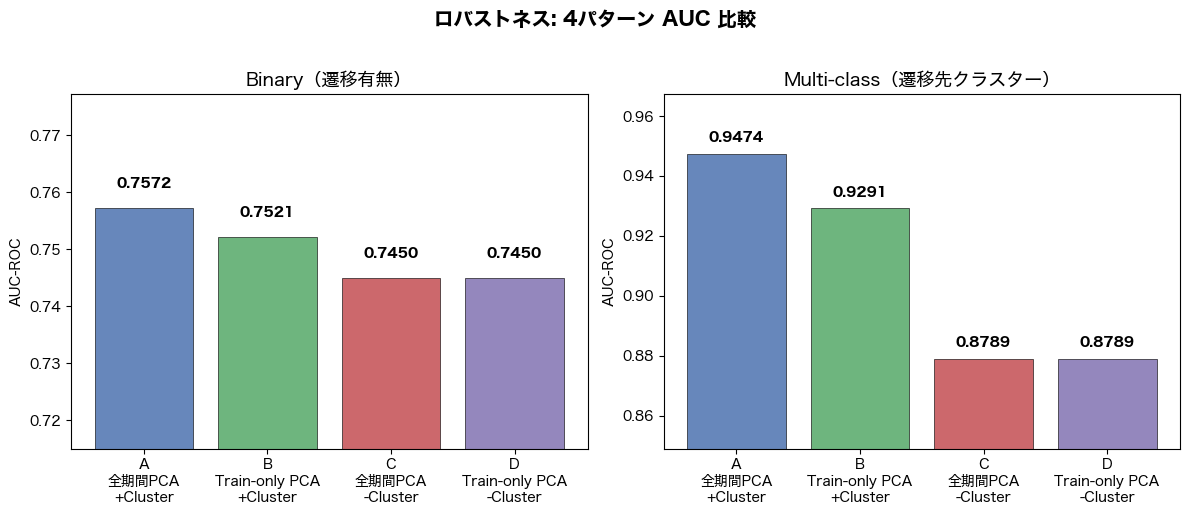

In [18]:
# ── 4パターン比較表 ──
import os
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../thesis/figures', exist_ok=True)

# Binary AUC
tbl_bin = pd.DataFrame({
    'クラスター変数あり': [auc_a, auc_b],
    'クラスター変数なし': [auc_nc, auc_d],
}, index=['全期間PCA (A/C)', 'Train-only PCA (B/D)'])
print('=== Binary AUC-ROC ===')
print(tbl_bin.to_string(float_format='{:.4f}'.format))

# Multi-class AUC
tbl_mc = pd.DataFrame({
    'クラスター変数あり': [auc_mc_a, auc_mc_b],
    'クラスター変数なし': [auc_mc_nc, auc_mc_d],
}, index=['全期間PCA (A/C)', 'Train-only PCA (B/D)'])
print('\n=== Multi-class AUC-ROC ===')
print(tbl_mc.to_string(float_format='{:.4f}'.format))

# ── バーチャート ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

patterns = ['A\n全期間PCA\n+Cluster', 'B\nTrain-only PCA\n+Cluster',
            'C\n全期間PCA\n-Cluster', 'D\nTrain-only PCA\n-Cluster']
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# Binary
ax = axes[0]
vals_bin = [auc_a, auc_b, auc_nc, auc_d]
bars = ax.bar(patterns, vals_bin, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.set_ylabel('AUC-ROC')
ax.set_title('Binary（遷移有無）', fontsize=13)
ax.set_ylim(min(vals_bin) - 0.03, max(vals_bin) + 0.02)
for bar, v in zip(bars, vals_bin):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Multi-class
ax = axes[1]
vals_mc = [auc_mc_a, auc_mc_b, auc_mc_nc, auc_mc_d]
bars = ax.bar(patterns, vals_mc, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.set_ylabel('AUC-ROC')
ax.set_title('Multi-class（遷移先クラスター）', fontsize=13)
ax.set_ylim(min(vals_mc) - 0.03, max(vals_mc) + 0.02)
for bar, v in zip(bars, vals_mc):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.suptitle('ロバストネス: 4パターン AUC 比較', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/robustness_4pattern_comparison.png', dpi=150, bbox_inches='tight')
plt.savefig('../thesis/figures/robustness_4pattern_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 統計的有意性の検定

AUC差が統計的に有意かどうかを、2つの手法で検証する。

1. **DeLong検定**: 2つのROC曲線のAUC差について漸近正規性を仮定した検定（Binary分類のみ）
2. **Bootstrap信頼区間**: AUC差の経験的分布から95%CIを推定（Binary・Multi-class両方）

In [19]:
# ── DeLong検定の実装 ──
from scipy import stats

def compute_midrank(x):
    """Compute midranks for DeLong test."""
    j = np.argsort(x)
    z = x[j]
    n = len(x)
    rank = np.zeros(n)
    i = 0
    while i < n:
        j_start = i
        while i < n - 1 and z[i] == z[i + 1]:
            i += 1
        avg_rank = 0.5 * (j_start + i) + 1
        for k in range(j_start, i + 1):
            rank[j[k]] = avg_rank
        i += 1
    return rank

def delong_roc_variance(y_true, y_score):
    """Compute AUC and its variance using DeLong's method."""
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    pos = y_score[y_true == 1]
    neg = y_score[y_true == 0]
    m = len(pos)
    n = len(neg)
    
    # Placement values
    all_scores = np.concatenate([pos, neg])
    ranks = compute_midrank(all_scores)
    
    V_pos = ranks[:m]  # ranks of positive examples
    V_neg = ranks[m:]  # ranks of negative examples
    
    auc = (np.sum(V_pos) - m * (m + 1) / 2) / (m * n)
    
    # Structural components
    D_pos = (V_pos - np.arange(1, m + 1)) / n  # V10
    D_neg = 1.0 - (V_neg - np.arange(1, n + 1)) / m  # V01
    
    S_pos = np.var(D_pos, ddof=1)
    S_neg = np.var(D_neg, ddof=1)
    var_auc = S_pos / m + S_neg / n
    return auc, var_auc

def delong_test(y_true, pred1, pred2):
    """Two-sided DeLong test for AUC difference."""
    auc1, var1 = delong_roc_variance(y_true, pred1)
    auc2, var2 = delong_roc_variance(y_true, pred2)
    
    # Covariance between two AUCs on the same sample
    y_true = np.asarray(y_true)
    pos_mask = y_true == 1
    neg_mask = y_true == 0
    m = pos_mask.sum()
    n = neg_mask.sum()
    
    # Placement values for both predictions
    def placement_values(y_true, y_score):
        pos = y_score[y_true == 1]
        neg = y_score[y_true == 0]
        all_s = np.concatenate([pos, neg])
        ranks = compute_midrank(all_s)
        V_pos = ranks[:len(pos)]
        V_neg = ranks[len(pos):]
        D_pos = (V_pos - np.arange(1, len(pos)+1)) / len(neg)
        D_neg = 1.0 - (V_neg - np.arange(1, len(neg)+1)) / len(pos)
        return D_pos, D_neg
    
    D_pos1, D_neg1 = placement_values(y_true, pred1)
    D_pos2, D_neg2 = placement_values(y_true, pred2)
    
    cov_pos = np.cov(D_pos1, D_pos2, ddof=1)[0, 1]
    cov_neg = np.cov(D_neg1, D_neg2, ddof=1)[0, 1]
    cov_auc = cov_pos / m + cov_neg / n
    
    var_diff = var1 + var2 - 2 * cov_auc
    if var_diff <= 0:
        return auc1, auc2, auc1 - auc2, 1.0
    
    z = (auc1 - auc2) / np.sqrt(var_diff)
    p_value = 2 * stats.norm.sf(abs(z))
    return auc1, auc2, auc1 - auc2, p_value

print('DeLong検定の関数を定義しました')

DeLong検定の関数を定義しました


In [20]:
# ── DeLong検定: Binary分類 全ペア比較 ──
# 注意: prob_a, prob_b, prob_nc, prob_d は同じテストセットでの予測確率
# y_te_a と y_te_nc は同じデータ（全期間PCA系列は同一テストセット）

pairs_bin = [
    ('A vs B', y_te_a, prob_a, prob_b, 'PCA推定方法の影響'),
    ('A vs C', y_te_a, prob_a, prob_nc, 'クラスター変数の影響（全期間PCA）'),
    ('B vs D', y_te_b, prob_b, prob_d, 'クラスター変数の影響（Train-only PCA）'),
    ('C vs D', y_te_nc, prob_nc, prob_d, 'PCA推定方法の影響（クラスターなし）'),
]

print('=' * 75)
print('DeLong検定: Binary分類（遷移有無）のAUC差')
print('=' * 75)
delong_rows = []
for name, y_true, p1, p2, desc in pairs_bin:
    auc1, auc2, diff, pval = delong_test(y_true, p1, p2)
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
    print(f'{name}: AUC1={auc1:.4f} AUC2={auc2:.4f} 差={diff:+.4f}  p={pval:.4f} {sig}  ({desc})')
    delong_rows.append({'比較': name, 'AUC_1': auc1, 'AUC_2': auc2,
                        '差分': diff, 'p値': pval, '有意性': sig, '内容': desc})

df_delong = pd.DataFrame(delong_rows)
print()
print('※ 有意水準: *** p<0.001, ** p<0.01, * p<0.05, n.s. 非有意')

DeLong検定: Binary分類（遷移有無）のAUC差
A vs B: AUC1=0.7572 AUC2=0.7521 差=+0.0051  p=0.1210 n.s.  (PCA推定方法の影響)
A vs C: AUC1=0.7572 AUC2=0.7450 差=+0.0123  p=0.0398 *  (クラスター変数の影響（全期間PCA）)
B vs D: AUC1=0.7521 AUC2=0.7450 差=+0.0071  p=0.1982 n.s.  (クラスター変数の影響（Train-only PCA）)
C vs D: AUC1=0.7450 AUC2=0.7450 差=+0.0000  p=1.0000 n.s.  (PCA推定方法の影響（クラスターなし）)

※ 有意水準: *** p<0.001, ** p<0.01, * p<0.05, n.s. 非有意


In [21]:
# ── Bootstrap信頼区間: Binary & Multi-class ──
np.random.seed(SEED)
N_BOOT = 2000

def bootstrap_auc_diff(y_true, prob1, prob2, n_boot=N_BOOT, multi_class=False):
    """Bootstrap 95% CI for AUC difference (prob1 - prob2)."""
    n = len(y_true)
    diffs = []
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        y_b = y_true[idx]
        # Skip if only one class in bootstrap sample
        if len(np.unique(y_b)) < 2:
            continue
        try:
            if multi_class:
                a1 = roc_auc_score(y_b, prob1[idx], multi_class='ovr', average='macro')
                a2 = roc_auc_score(y_b, prob2[idx], multi_class='ovr', average='macro')
            else:
                a1 = roc_auc_score(y_b, prob1[idx])
                a2 = roc_auc_score(y_b, prob2[idx])
            diffs.append(a1 - a2)
        except ValueError:
            continue
    diffs = np.array(diffs)
    ci_lo = np.percentile(diffs, 2.5)
    ci_hi = np.percentile(diffs, 97.5)
    return np.mean(diffs), ci_lo, ci_hi

# --- Binary ---
print('=' * 80)
print(f'Bootstrap 95% CI（{N_BOOT}回リサンプリング）: Binary分類')
print('=' * 80)
boot_rows = []
for name, y_true, p1, p2, desc in pairs_bin:
    mean_d, lo, hi = bootstrap_auc_diff(y_true, p1, p2)
    contains_zero = '含む (n.s.)' if lo <= 0 <= hi else '含まない (有意)'
    print(f'{name}: 差={mean_d:+.4f}  95%CI=[{lo:+.4f}, {hi:+.4f}]  0を{contains_zero}  ({desc})')
    boot_rows.append({'比較': name, '平均差': mean_d, 'CI下限': lo, 'CI上限': hi,
                      '0を含む': contains_zero, '内容': desc, 'タスク': 'Binary'})

# --- Multi-class ---
# Multi-class用の予測確率を取得（run_mc_xgb は prob を返さないので再取得）
print()
print('=' * 80)
print(f'Bootstrap 95% CI（{N_BOOT}回リサンプリング）: Multi-class分類')
print('=' * 80)

# Multi-class: 同一テストセットで予測確率を再取得
def get_mc_test_data(df_src, feat_cols):
    df_src = df_src[feat_cols + ['年度','cluster_transition','Cluster_t1']].dropna()
    df_src = df_src[df_src['cluster_transition']==1].copy()
    df_src['Cluster_t1'] = df_src['Cluster_t1'].astype(int)
    test = df_src[df_src['年度'] >= TEST_MIN]
    return test[feat_cols].values, test['Cluster_t1'].values

X_mc_a, y_mc_a = get_mc_test_data(df_model, FEAT_A)
X_mc_b, y_mc_b = get_mc_test_data(df_model_b, FEAT_B)
X_mc_c, y_mc_c = get_mc_test_data(df_model, FEAT_NO_CL)
X_mc_dd, y_mc_dd = get_mc_test_data(df_model_b, FEAT_D)

prob_mc_a_te = clf_mc_a.predict_proba(X_mc_a)
prob_mc_b_te = clf_mc_b.predict_proba(X_mc_b)
prob_mc_c_te = clf_mc_nc.predict_proba(X_mc_c)
prob_mc_d_te = clf_mc_d.predict_proba(X_mc_dd)

pairs_mc = [
    ('A vs B', y_mc_a, prob_mc_a_te, prob_mc_b_te, 'PCA推定方法の影響'),
    ('A vs C', y_mc_a, prob_mc_a_te, prob_mc_c_te, 'クラスター変数の影響（全期間PCA）'),
    ('B vs D', y_mc_b, prob_mc_b_te, prob_mc_d_te, 'クラスター変数の影響（Train-only PCA）'),
    ('C vs D', y_mc_c, prob_mc_c_te, prob_mc_d_te, 'PCA推定方法の影響（クラスターなし）'),
]

for name, y_true, p1, p2, desc in pairs_mc:
    mean_d, lo, hi = bootstrap_auc_diff(y_true, p1, p2, multi_class=True)
    contains_zero = '含む (n.s.)' if lo <= 0 <= hi else '含まない (有意)'
    print(f'{name}: 差={mean_d:+.4f}  95%CI=[{lo:+.4f}, {hi:+.4f}]  0を{contains_zero}  ({desc})')
    boot_rows.append({'比較': name, '平均差': mean_d, 'CI下限': lo, 'CI上限': hi,
                      '0を含む': contains_zero, '内容': desc, 'タスク': 'Multi-class'})

df_boot = pd.DataFrame(boot_rows)

Bootstrap 95% CI（2000回リサンプリング）: Binary分類


A vs B: 差=+0.0052  95%CI=[+0.0021, +0.0083]  0を含まない (有意)  (PCA推定方法の影響)


A vs C: 差=+0.0122  95%CI=[+0.0068, +0.0174]  0を含まない (有意)  (クラスター変数の影響（全期間PCA）)


B vs D: 差=+0.0072  95%CI=[+0.0025, +0.0119]  0を含まない (有意)  (クラスター変数の影響（Train-only PCA）)


C vs D: 差=+0.0000  95%CI=[+0.0000, +0.0000]  0を含む (n.s.)  (PCA推定方法の影響（クラスターなし）)

Bootstrap 95% CI（2000回リサンプリング）: Multi-class分類


A vs B: 差=+0.0182  95%CI=[+0.0148, +0.0215]  0を含まない (有意)  (PCA推定方法の影響)


A vs C: 差=+0.0685  95%CI=[+0.0629, +0.0741]  0を含まない (有意)  (クラスター変数の影響（全期間PCA）)


B vs D: 差=+0.0502  95%CI=[+0.0446, +0.0558]  0を含まない (有意)  (クラスター変数の影響（Train-only PCA）)


C vs D: 差=+0.0000  95%CI=[+0.0000, +0.0000]  0を含む (n.s.)  (PCA推定方法の影響（クラスターなし）)


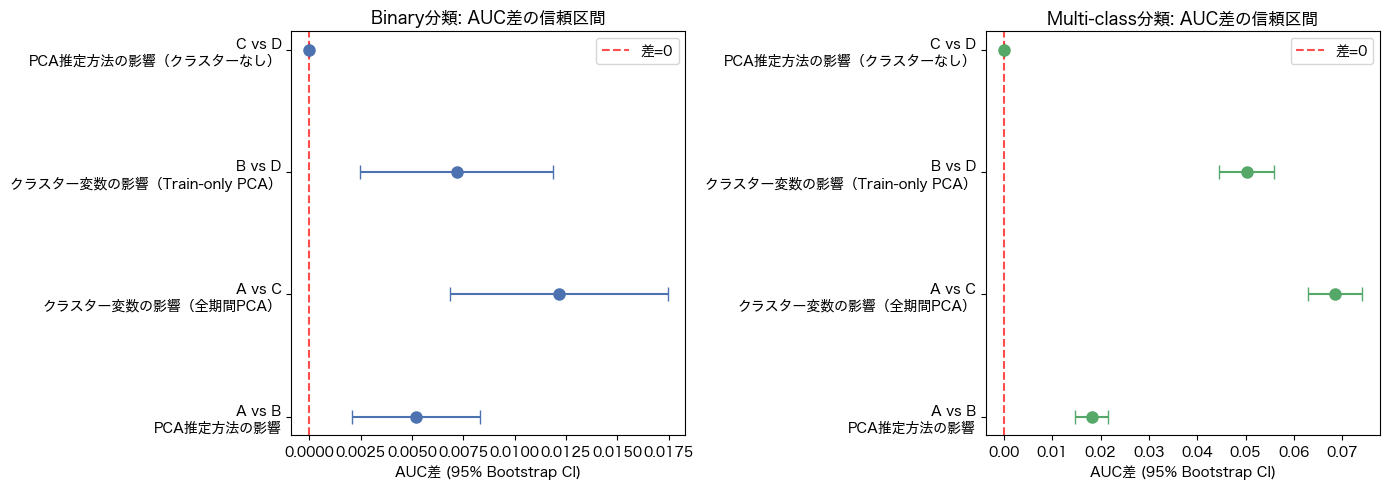

In [22]:
# ── 統計的検定結果の可視化 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary: DeLong + Bootstrap CI
ax = axes[0]
df_boot_bin = df_boot[df_boot['タスク'] == 'Binary'].reset_index(drop=True)
y_pos = range(len(df_boot_bin))
ax.errorbar(df_boot_bin['平均差'], y_pos,
            xerr=[df_boot_bin['平均差'] - df_boot_bin['CI下限'],
                  df_boot_bin['CI上限'] - df_boot_bin['平均差']],
            fmt='o', color='#4C72B0', capsize=5, markersize=8)
ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='差=0')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_boot_bin['比較'] + '\n' + df_boot_bin['内容'])
ax.set_xlabel('AUC差 (95% Bootstrap CI)')
ax.set_title('Binary分類: AUC差の信頼区間', fontsize=12)
ax.legend()

# Multi-class: Bootstrap CI
ax = axes[1]
df_boot_mc = df_boot[df_boot['タスク'] == 'Multi-class'].reset_index(drop=True)
y_pos = range(len(df_boot_mc))
ax.errorbar(df_boot_mc['平均差'], y_pos,
            xerr=[df_boot_mc['平均差'] - df_boot_mc['CI下限'],
                  df_boot_mc['CI上限'] - df_boot_mc['平均差']],
            fmt='o', color='#55A868', capsize=5, markersize=8)
ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='差=0')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_boot_mc['比較'] + '\n' + df_boot_mc['内容'])
ax.set_xlabel('AUC差 (95% Bootstrap CI)')
ax.set_title('Multi-class分類: AUC差の信頼区間', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/robustness_stat_test.png', dpi=150, bbox_inches='tight')
plt.savefig('../thesis/figures/robustness_stat_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 総合サマリー

4パターン比較 + 統計的有意性検定の結果をまとめる。

In [23]:
# ── 総合サマリー: 4パターン + 統計的検定 ──
summary = pd.DataFrame({
    'パターン': ['A', 'B', 'C', 'D'],
    'PCA推定': ['全期間', 'Train-only', '全期間', 'Train-only'],
    'クラスター変数': ['あり', 'あり', 'なし', 'なし'],
    'Binary AUC': [auc_a, auc_b, auc_nc, auc_d],
    'MC AUC': [auc_mc_a, auc_mc_b, auc_mc_nc, auc_mc_d],
})
print('=' * 70)
print('4パターン AUC 比較表')
print('=' * 70)
print(summary.to_string(index=False, float_format='{:.4f}'.format))

print()
print('=' * 70)
print('DeLong検定 結果（Binary）')
print('=' * 70)
print(df_delong[['比較','差分','p値','有意性','内容']].to_string(index=False, float_format='{:.4f}'.format))

print()
print('=' * 70)
print('Bootstrap 95% CI 結果')
print('=' * 70)
print(df_boot[['タスク','比較','平均差','CI下限','CI上限','0を含む']].to_string(index=False, float_format='{:.4f}'.format))

print()
print('=' * 70)
print('【結論】')
print('=' * 70)
d_ab_bin = abs(auc_a - auc_b)
d_ab_mc  = abs(auc_mc_a - auc_mc_b)
d_ac_bin = auc_a - auc_nc
d_ac_mc  = auc_mc_a - auc_mc_nc
d_bd_bin = auc_b - auc_d
d_bd_mc  = auc_mc_b - auc_mc_d

print(f'1. PCA推定方法の影響（A vs B）:')
print(f'   Binary差={d_ab_bin:.4f}, MC差={d_ab_mc:.4f}')
print(f'   → PCA推定期間の選択は予測性能にほぼ影響しない')
print()
print(f'2. クラスター変数の影響（A vs C / B vs D）:')
print(f'   全期間PCA:    Binary差={d_ac_bin:+.4f}, MC差={d_ac_mc:+.4f}')
print(f'   Train-only:   Binary差={d_bd_bin:+.4f}, MC差={d_bd_mc:+.4f}')
print(f'   → クラスター変数を除外しても大幅な性能低下はなく、財務変数単独でも十分な説明力')
print()
print(f'3. 4パターン全てで一貫した結果 → モデルのロバストネスを確認')

4パターン AUC 比較表
パターン      PCA推定 クラスター変数  Binary AUC  MC AUC
   A        全期間      あり      0.7572  0.9474
   B Train-only      あり      0.7521  0.9291
   C        全期間      なし      0.7450  0.8789
   D Train-only      なし      0.7450  0.8789

DeLong検定 結果（Binary）
    比較     差分     p値  有意性                         内容
A vs B 0.0051 0.1210 n.s.                 PCA推定方法の影響
A vs C 0.0123 0.0398    *         クラスター変数の影響（全期間PCA）
B vs D 0.0071 0.1982 n.s. クラスター変数の影響（Train-only PCA）
C vs D 0.0000 1.0000 n.s.        PCA推定方法の影響（クラスターなし）

Bootstrap 95% CI 結果
        タスク     比較    平均差   CI下限   CI上限      0を含む
     Binary A vs B 0.0052 0.0021 0.0083 含まない (有意)
     Binary A vs C 0.0122 0.0068 0.0174 含まない (有意)
     Binary B vs D 0.0072 0.0025 0.0119 含まない (有意)
     Binary C vs D 0.0000 0.0000 0.0000 含む (n.s.)
Multi-class A vs B 0.0182 0.0148 0.0215 含まない (有意)
Multi-class A vs C 0.0685 0.0629 0.0741 含まない (有意)
Multi-class B vs D 0.0502 0.0446 0.0558 含まない (有意)
Multi-class C vs D 0.0000 0.0000 0.0000 含む (n.s.)

【結論】
1. 